#Nastavení prostředí

In [ ]:
!git clone https://github.com/TomasFAV/InvoiceCzech.git /content/InvoiceCzech

Cloning into '/content/InvoiceCzech'...
remote: Enumerating objects: 481, done.
remote: Counting objects: 100% (83/83), done.
remote: Compressing objects: 100% (46/46), done.
remote: Total 481 (delta 37), reused 55 (delta 22), pack-reused 398 (from 1)
Receiving objects: 100% (481/481), 40.02 MiB | 10.76 MiB/s, done.
Resolving deltas: 100% (89/89), done.


In [ ]:
!apt-get install tesseract-ocr-ces

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tesseract-ocr-ces
0 upgraded, 1 newly installed, 0 to remove and 37 not upgraded.
Need to get 1,408 kB of archives.
After this operation, 3,810 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-ces all 1:4.00~git30-7274cfa-1.1 [1,408 kB]
Fetched 1,408 kB in 1s (963 kB/s)
Selecting previously unselected package tesseract-ocr-ces.
(Reading database ... 121852 files and directories currently installed.)
Preparing to unpack .../tesseract-ocr-ces_1%3a4.00~git30-7274cfa-1.1_all.deb ...
Unpacking tesseract-ocr-ces (1:4.00~git30-7274cfa-1.1) ...
Setting up tesseract-ocr-ces (1:4.00~git30-7274cfa-1.1) ...


In [ ]:
!pip install python-Levenshtein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 108.9 MB/s eta 0:00:00


In [ ]:
!pip install -q pytesseract

In [ ]:
!pip install zss

  Preparing metadata (setup.py) ... done
  Created wheel for zss: filename=zss-1.2.0-py3-none-any.whl size=6725 sha256=800f7bd1ed74b6901c0aef16fb8bf5376204cfbc542a6a3de765281bcf126082
  Stored in directory: /root/.cache/pip/wheels/46/e7/2e/44fb39352ad468427a7528cacbefefaa438a898dfd1ad2eaa4
Successfully built zss


In [ ]:
from zss import Node
import zss
from nltk import edit_distance

In [ ]:
from tqdm.auto import tqdm
import torch
import json
from collections import Counter, defaultdict
from Levenshtein import distance as lev_distance
import re

import numpy as np

In [ ]:
DATASET_ID = "TomasFAV/RealDocumentInvoiceCzech"
MODEL_ID = "TomasFAV/LiLTInvoiceCzechV3"
device = "cuda" if torch.cuda.is_available() else "cpu"

#DATASET

In [ ]:
from datasets import load_dataset

val_dataset = load_dataset(DATASET_ID, split="train")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/13.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/39 [00:00<?, ? examples/s]

#Model


In [ ]:
from transformers import AutoProcessor
from transformers import AutoModelForTokenClassification

processor = AutoProcessor.from_pretrained(MODEL_ID, apply_ocr=False)
model = AutoModelForTokenClassification.from_pretrained(MODEL_ID)

model.to(device)

tokenizer_config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/521M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/400 [00:00<?, ?it/s]

LiltForTokenClassification(
  (lilt): LiltModel(
    (embeddings): LiltTextEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (layout_embeddings): LiltLayoutEmbeddings(
      (x_position_embeddings): Embedding(1024, 128)
      (y_position_embeddings): Embedding(1024, 128)
      (h_position_embeddings): Embedding(1024, 128)
      (w_position_embeddings): Embedding(1024, 128)
      (box_position_embeddings): Embedding(514, 192, padding_idx=1)
      (box_linear_embeddings): Linear(in_features=768, out_features=192, bias=True)
      (LayerNorm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): LiltEncoder(
      (layer): ModuleList(
        (0-11): 12 x Lil

#Metriky

In [ ]:
from InvoiceCzech.evaluation_utils.utils import *

#EVALUACE

In [ ]:
@torch.no_grad()
def evaluate(
    model,
    processor,
    dataset,
    device,
    max_length=512,
    limit=None,
    verbose=False,
    print_limit=None,
    only_mismatches=False,
    show_raw_generated_text=False
):
    model.eval()
    id2label = model.config.id2label

    n = len(dataset)
    if limit is not None: n = min(n, limit)

    ground_truths = list()
    predictions = list()

    # tqdm lišta s popiskem
    pbar = tqdm(range(n), desc="Evaluating model")

    for i in pbar:
        sample = dataset[i]
        image = sample["image"]

        # --- Ground Truth (GT) ---
        gt_raw = sample.get("ground_truth", None)
        gt_obj = json.loads(gt_raw) if isinstance(gt_raw, str) else gt_raw
        gt_json_raw = gt_obj.get("gt_parse", gt_obj)
        gt_dict = gt_json_raw

        pred_dict = defaultdict(str)

        for key,value in gt_dict.items():
          pred_dict[key] = ""

        # --- Prediction ---
        words, boxes = get_ocr_data_for_layoutlm(image)

        encoding = processor(
            words,
            boxes=boxes,
            return_tensors="pt",
            return_overflowing_tokens=True,
            return_offsets_mapping=True,
            max_length=max_length,
            stride=128,
            padding="max_length",
            truncation=True,
            is_split_into_words=True,
        ).to(device)

        offset_mapping = encoding.pop('offset_mapping')
        encoding.pop('overflow_to_sample_mapping', None)

        outputs = model(**encoding)
        all_predictions = outputs.logits.argmax(-1) # [num_chunks, seq_len]


        # --- Stitching (BIO Logic) ---
        current_entity_words = []
        current_label = None

        for window_idx in range(all_predictions.shape[0]):
            predictions_tensor = all_predictions[window_idx]
            word_ids = encoding.word_ids(window_idx)
            last_word_idx = None

            for idx, pred_id in enumerate(predictions_tensor):
                curr_word_idx = word_ids[idx]
                if curr_word_idx is None or curr_word_idx == last_word_idx:
                    continue

                label_name = id2label[pred_id.item()]
                word_text = words[curr_word_idx]

                if label_name.startswith("B_"):
                    if current_label and current_entity_words:
                        k_clean = normalize_text(current_label)
                        k_mapped = k_clean
                        if k_mapped == "payment_type":
                          pred_dict[k_mapped] = " ".join(current_entity_words).strip()
                        else:
                          pred_dict[k_mapped] = "".join(current_entity_words).strip()
                    current_label = label_name[2:]
                    current_entity_words = [word_text]
                elif label_name.startswith("I_") and current_label == label_name[2:]:
                    current_entity_words.append(word_text)
                else:
                    if current_label and current_entity_words:
                        k_clean = normalize_text(current_label)
                        k_mapped = k_clean
                        if k_mapped == "payment_type":
                          pred_dict[k_mapped] = " ".join(current_entity_words).strip()
                        else:
                          pred_dict[k_mapped] = "".join(current_entity_words).strip()
                    current_label = None
                    current_entity_words = []
                last_word_idx = curr_word_idx

        if current_label and current_entity_words:
            k_clean = normalize_text(current_label)
            k_mapped = k_clean
            if k_mapped == "payment_type":
              pred_dict[k_mapped] = " ".join(current_entity_words).strip()
            else:
              pred_dict[k_mapped] = "".join(current_entity_words).strip()
        # --- Metriky ---
        clean_gt_json = gt_dict
        clean_pred_json = pred_dict


        ground_truths.append(clean_gt_json)
        predictions.append(clean_pred_json) # Append to the correct list

        metrics = compute_metrics(predictions, ground_truths)

        pbar.set_postfix(metrics)


    field_level = field_level_f1(predictions, ground_truths)
    plot_field_level_f1(field_level[0])
    print(field_level[1])

    return metrics

Evaluating model:   0%|          | 0/39 [00:00<?, ?it/s]

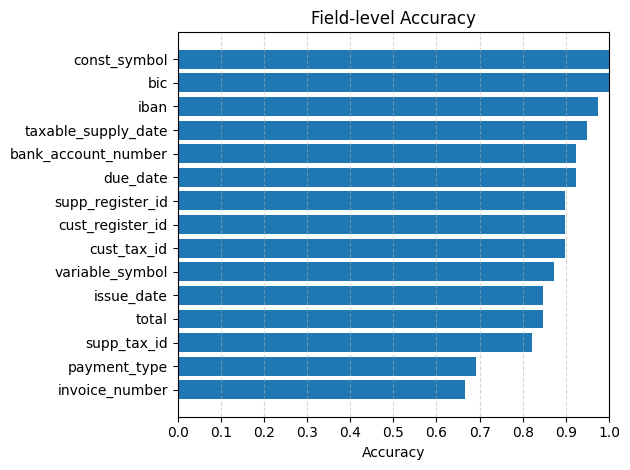

defaultdict(<class 'list'>, {'payment_type': [('platba dobírkou', 'platba na dobírku'), ('hotovosti kurýrovi', 'dobírkou'), ('google pay me.', 'google pay'), ('platba dobírkou', 'platba na dobírku'), ('platba', 'platba v odběrném místě'), ('oko', 'online kreditní kartou'), ('', 'platební kartou online'), ('panně', 'platební kartou'), ('online platbou!', 'kartou online'), ('google', 'google pay'), ('', 'platební karta'), ('google pay me.', 'google pay')], 'total': [('293,00', '1213,00'), ('765', '268,00'), ('', '1228'), ('1337,00', '1377,00'), ('40', '3688,00'), ('', '651')], 'cust_tax_id': [('sk2023008911', ''), ('2021680991', ''), ('cz08139105', ''), ('cz09336273', '')], 'supp_tax_id': [('', 'sk2023008911'), ('', 'sk7020001021'), ('', 'cz08139105'), ('cz54123467', 'cz27082440'), ('cz', 'cz27082440'), ('', 'cz09336273'), ('cz01287439', 'cz27082440')], 'invoice_number': [('222463191', '2224631911'), ('', '2216903387'), ('', '2963371283'), ('6402453', '5151-2007/2024'), ('', '2947609007'

In [ ]:
results = evaluate(model, processor, val_dataset, device, verbose=True)